In [116]:
import os
# import plumbum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# import argparse
# import plotly.graph_objects as go

from pandas.tseries.offsets import CustomBusinessDay
from pandas.tseries.holiday import USFederalHolidayCalendar

from typing import Union, Literal
from tqdm import tqdm
from pathlib import Path
from loguru import logger
from beartype import beartype


In [2]:
# !pip3 install tqdm


In [ ]:
import os
# import plumbum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
import argparse
# import plotly.graph_objects as go

from pandas.tseries.offsets import CustomBusinessDay
from pandas.tseries.holiday import USFederalHolidayCalendar

from typing import Union, Literal
from tqdm import tqdm
from pathlib import Path
from loguru import logger
from beartype import beartype


NAMES = [
    'ETF ISIN',
    'ETF Meta',
    'ETF MetaFiltered',
    'OpenPrice',
    'LastPrice',
    'MinPrice',
    'MaxPrice',
    'Volume',
    'AUM (USD)',
    'ETFs',
    'DistrAmount',
    'PayableDate',
    'ETF Trading'
]


@beartype
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    parser.add_argument("--path", "-p", help="Path for xslx eft data", type=str, required=True)
    # parser.add_argument("--output", "-o", help="Folder Path for saving files", type=str, required=True)
    return parser.parse_args()


@beartype
def read_excel_data(path: Path) -> Union[dict, pd.DataFrame]:
    try:
        return pd.read_excel(path, sheet_name=NAMES, index_col=None)
    except FileNotFoundError:
        raise FileNotFoundError(f"File not found: {path}")
    except Exception as e:
        raise ValueError(f"Could not parse file {path}: {e}")
    

@beartype
def get_summary(
    df_dict: dict[str, pd.DataFrame],
    COLS_NAMES: list,
    merging_name: Union[str, list],
    merging_type: Literal['left', 'right', 'outer', 'inner', 'cross'] = 'inner',
    save_path: Union[Path, None] = None
) -> pd.DataFrame:

    merged_df = pd.DataFrame()
    for name in tqdm(COLS_NAMES, desc='Summary Process'):
        df = df_dict[name]
        if merging_name in df.columns:
            merged_df = pd.merge(merged_df, df, how=merging_type, on=merging_name) if not merged_df.empty else df
        
        else:
            logger.info(f'For Summary skip dict key {name}')
            
    if save_path:
        merged_df.to_csv(save_path / 'summary.csv')
    
    return merged_df


@beartype
def get_etf_codes(df: pd.DataFrame, name: str) -> list:
    """
    we know that name == 'ISIN' a code, but using general function for further using
    """
    try:
        return df[name].tolist()
    except:
        raise ValueError(f"Column name {name} doesn't exist in this Dataframe or maybe dataframe is empty")
    
    
def filter_business_dates(df: Union[dict[str, pd.DataFrame], pd.DataFrame]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:
    def sort_dates(df: pd.DataFrame) -> pd.DataFrame:
        if 'Date' in df.columns:
            df = df.sort_values('Date')
            return df.reset_index(drop=True)

        return df
    
    def get_only_business_dates(df: pd.DataFrame) -> pd.DataFrame:
        """
        Removing weekends (that's Saturday and Sunday, saving only dates from Monday to Friday inclusive) and removing holidays
        """
        if 'Date' in df.columns:
            all_business_dates = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq=CustomBusinessDay(calendar=USFederalHolidayCalendar()))
            df = df[df['Date'].isin(all_business_dates)]
        
        return df.reset_index(drop=True)
    
    if isinstance(df, dict):
        for code in df.keys():
            df[code] = sort_dates(df[code])
            df[code] = get_only_business_dates(df[code])
        
    elif isinstance(df, pd.DataFrame):
        df = sort_dates(df)
        df = get_only_business_dates(df)
        
    else:
        raise TypeError(f'Wrong type of df {type(df)}')
    
    return df

    
# @beartype
# def remove_weekends(df: pd.DataFrame) -> pd.DataFrame:
#     """
#     Removing weekends (that's Saturday and Sunday, saving only dates from Monday to Friday inclusive)
#     """
#     try:
#         return df[df['Date'].dt.weekday < 5]
#     except:
#         raise ValueError(f"Column name 'Date' doesn't exist in this Dataframe or maybe dataframe is empty")

    
# @beartype
# def remove_no_data(df: pd.DataFrame) -> pd.DataFrame:
#     def is_all_row_no_data(row):
#         return all(x == 'No data' for x in row)
    
#     mask = df[df.columns[1:]].apply(is_all_row_no_data, axis=1)
#     return df[~mask]


@beartype
def sort_dates(df: Union[dict[str, pd.DataFrame], pd.DataFrame]) -> Union[dict, pd.DataFrame]:
    if isinstance(df, dict):
        for key in df.keys():
            df[key] = df[key].sort_values('Date')
            df[key] = df[key].reset_index(drop=True)
    
    elif isinstance(df, pd.DataFrame):
        df = df.sort_values('Date')
        df = df.reset_index(drop=True)

    else:
        raise TypeError("DataFrame is empty or column 'Date' doesn't exist in DataFrame")
        
    return df


@beartype
def cosmetic_changes(df: Union[dict[str, pd.DataFrame], pd.DataFrame]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:
    def replace(df: pd.DataFrame) -> pd.DataFrame:
        for col in df.columns[1:]:
            df[col] = df[col].mask(df[col] == 'No data', np.nan)
            if any(',' in str(x) for x in df[col]): df[col] = df[col].str.replace(',', '.').astype('float')
            if any(str(x).count('.') == 2 for x in df[col]): df[col] = pd.to_datetime(df[col].str.replace('.', '-'), dayfirst=True)

        return df
        
    if isinstance(df, dict):
        for code in df.keys():
            df[code] = replace(df[code])
    
    elif isinstance(df, pd.DataFrame):
        df = replace(df)
    
    else:
        raise TypeError("DataFrame is empty or column 'Date' doesn't exist in DataFrame")
        
    return df


def filling_values(df: Union[dict[str, pd.DataFrame]]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:    
    def fill_na_values(df: pd.Series, window=20) -> pd.Series:
        # Special condition that check if all values of series is numbers, not strings
        if not np.issubdtype(df.dtype, np.number):
            return df
        
        start = df.index[~df.isna()][0]
        end = len(df)
        
        df = df.copy()
        for i in range(start, end):
            if pd.isna(df.iloc[i]):
                df.iloc[i] = df.iloc[start:i].mean() if i - start < window else df.iloc[i-window-1:i].mean()
                
        return df
    
    def fill_df(df: pd.DataFrame) -> pd.DataFrame:
        for i in df.columns[1:-1]:
            df[i] = fill_na_values(df[i])            
        return df
    
    if isinstance(df, dict):
        for code in df.keys():
            df[code] = fill_df(df[code])
        return df
                
    elif isinstance(df, pd.DataFrame):
        return fill_df(df)
    
    else:
        raise TypeError("DataFrame is empty or column 'Date' doesn't exist in DataFrame")
    
    
def estimate_midPrice(
    df: pd.DataFrame,
    code: str,
    method: Literal['Average OHLC', 'Average HL'] = 'Average HL'
) -> pd.DataFrame:

    if set([f'MaxPrice {code}', f'MinPrice {code}', f'OpenPrice {code}', f'LastPrice {code}']) <= set(df.columns):
        if method == 'Average HL':
            df[f'MidPrice {code}'] = 0.5 * (df[f'MaxPrice {code}'] + df[f'MinPrice {code}'])
        
        else:
            df[f'MidPrice {code}'] = 0.25 * (df[f'MaxPrice {code}'] + df[f'MinPrice {code}'] + df[f'Openrice {code}'] + df[f'LastPrice {code}'])
            
    return df
    
    
@beartype
def estimate_BidAsk_spread(
    df: Union[dict[str, pd.DataFrame]],
    tickers: Union[list[str], str],
    method: Literal['High-Low-Ratio', 'High-Low-Corwin'] = 'High-Low-Corwin'
) -> Union[dict[str, pd.DataFrame]]:
    
    def calculate_spread(df: pd.DataFrame, code: str, method: Literal['High-Low-Ratio', 'High-Low-Corwin']) -> pd.DataFrame:
        if set([f'MaxPrice {code}', f'MinPrice {code}']) <= set(df.columns):
            df = estimate_midPrice(df, code)
            if method == 'High-Low-Ratio':
                df[f'Spread {code}'] = (df[f'MaxPrice {code}'] - df[f'MinPrice {code}']) / df[f'MidPrice {code}']
            
            elif method == 'High-Low-Corwin':
                high_1, high_2 = df[f'MaxPrice {code}'], df[f'MaxPrice {code}'].shift(1)
                low_1, low_2 = df[f'MinPrice {code}'], df[f'MinPrice {code}'].shift(1)
                
                const = 3 - 2 * np.sqrt(2)
                beta = (np.log(high_1/low_1)**2 + np.log(high_2/low_2)**2).rolling(2).sum()
                gamma = np.log(np.maximum(high_1, high_2) / np.minimum(low_1, low_2))**2
                
                alpha = (np.sqrt(2) - 1) * np.sqrt(beta) / const - np.sqrt(gamma / const)
                alpha = np.clip(alpha, a_min=0, a_max=None)
                df[f'Spread {code}'] = 2 * (np.exp(alpha) - 1) / (np.exp(alpha) + 1)
            
            else:
                return df
           
        return df
        
    if isinstance(df, dict) and isinstance(tickers, list):
        for code, ticker in zip(df.keys(), tickers):
            df[code] = calculate_spread(df[code], ticker, method)
        
    elif isinstance(df, pd.DataFrame) and isinstance(tickers, str):
        df = calculate_spread(df, tickers, method)
        
    else:
        raise TypeError(f'Wrong type of df {type(df)} and wrong type of code {type(df)}')
    
    return df


def estimate_BidAsk_Prices(df: Union[dict[str, pd.DataFrame]], tickers: Union[list[str], str]) -> Union[dict[str, pd.DataFrame]]:
    def calculate_bid_ask(df: pd.DataFrame, code: str) -> pd.DataFrame:
        if set([f'MidPrice {code}', f'Spread {code}']) <= set(df.columns):
            spread, mid = df[f'Spread {code}'], df[f'MidPrice {code}']
            df[f'AskPrice {code}'] = mid + 0.5 * spread
            df[f'BidPrice {code}'] = mid - 0.5 * spread
        
        return df
    
    if isinstance(df, dict) and isinstance(tickers, list):
        for code, ticker in zip(df.keys(), tickers):
            df[code] = calculate_bid_ask(df[code], ticker)
        
    elif isinstance(df, pd.DataFrame) and isinstance(tickers, str):
        df = calculate_bid_ask(df, tickers)
        
    else:
        raise TypeError(f'Wrong type of df {type(df)} and wrong type of code {type(df)}')
    
    return df


@beartype
def get_merge_statistics(
    df_dict: dict[str, pd.DataFrame],
    etf_ids: dict,
    save_path: Union[Path, None] = None
) -> dict[str, pd.DataFrame]:

    etf_codes = etf_ids.keys()
    df_stats = {code: pd.DataFrame() for code in etf_codes}
    
    for name in tqdm(NAMES, desc='Merging Process'):
        df = df_dict[name]
        if set(etf_codes) <= set(df.columns):
            # df = remove_weekends(df)
            df = df.rename(columns={col: f'{name} {etf_ids[col]}' for col in df.columns[1:]})
            
            for code in etf_codes:
                df_stats[code] = pd.merge(df_stats[code], df[['Date', f'{name} {etf_ids[code]}']], on='Date') if not df_stats[code].empty else df[['Date', f'{name} {etf_ids[code]}']]

        else:
            logger.info(f'For Statistics skip dict key {name}')
            
    # df_stats = sort_dates(df_stats)
    df_stats = cosmetic_changes(df_stats)
    df_stats = filling_values(df_stats)
    
    # The question is here do we need to use remove 'No data' and then with merging_type = 'outer' merge dataframes or not
    # for code in etf_codes:
    #     df_stats[code] = remove_no_data(df_stats[code])
        
    if save_path:
        for code in etf_codes:
            df_stats.to_csv(save_path / f"statistics_{etf_ids[code]}.csv")
        
    return df_stats


@beartype
def main(path: Path, save_path: Union[Path, None] = None) -> dict[str, pd.DataFrame]:
    try:
        df_dict = read_excel_data(path)
        df_dict = filter_business_dates(df_dict)
        
        summary_df = get_summary(df_dict, COLS_NAMES=NAMES, merging_name='ISIN', save_path=save_path)
        codes = get_etf_codes(summary_df, 'ISIN')
        tickers = get_etf_codes(summary_df, 'Тикер')
        etf_ids = {key: value for key, value in zip(codes, tickers)}
        
        df_stats = get_merge_statistics(df_dict, etf_ids, save_path)
        
        df_stats = estimate_BidAsk_spread(df_stats, tickers)
        df_stats = estimate_BidAsk_Prices(df_stats, tickers)
        
        # all_etf_stats = get_summary(df_stats, COLS_NAMES=codes, merging_name='Date', save_path=save_path)
        return df_stats
    
    except:
        logger.info(f"Skip main functon for {path}")
        
        
# if __name__ == "__main__":
#     args = parse_args()
#     # main(Path(args.path), Path(args.output))
#     main(Path(args.path), None)
#     logger.info("SUCCESS")


In [4]:
save_path = None
path = Path("../datasets/Portfolio ETF NASDAQ Data.xlsx")
os.path.exists(path)


True

In [ ]:
df_stats = main(path, save_path)
df_stats


Summary Process:   0%|          | 0/13 [00:00<?, ?it/s]2026-02-01 19:42:36.040 | INFO     | __main__:get_summary:71 - For Summary skip dict key OpenPrice
2026-02-01 19:42:36.040 | INFO     | __main__:get_summary:71 - For Summary skip dict key LastPrice
2026-02-01 19:42:36.041 | INFO     | __main__:get_summary:71 - For Summary skip dict key MinPrice
2026-02-01 19:42:36.041 | INFO     | __main__:get_summary:71 - For Summary skip dict key MaxPrice
2026-02-01 19:42:36.041 | INFO     | __main__:get_summary:71 - For Summary skip dict key Volume
2026-02-01 19:42:36.041 | INFO     | __main__:get_summary:71 - For Summary skip dict key AUM (USD)
2026-02-01 19:42:36.041 | INFO     | __main__:get_summary:71 - For Summary skip dict key ETFs
2026-02-01 19:42:36.042 | INFO     | __main__:get_summary:71 - For Summary skip dict key DistrAmount
2026-02-01 19:42:36.042 | INFO     | __main__:get_summary:71 - For Summary skip dict key PayableDate
2026-02-01 19:42:36.042 | INFO     | __main__:get_summary:71

{'US00039J8062':            Date  OpenPrice BUFC  LastPrice BUFC  MinPrice BUFC  MaxPrice BUFC  \
 0    2016-01-04             NaN             NaN            NaN            NaN   
 1    2016-01-05             NaN             NaN            NaN            NaN   
 2    2016-01-06             NaN             NaN            NaN            NaN   
 3    2016-01-07             NaN             NaN            NaN            NaN   
 4    2016-01-08             NaN             NaN            NaN            NaN   
 ...         ...             ...             ...            ...            ...   
 2499 2025-12-24           41.47         41.4400        41.3600          41.49   
 2500 2025-12-26           41.43         41.4213        41.4213          41.49   
 2501 2025-12-29           41.48         41.4500        41.3500          41.48   
 2502 2025-12-30           41.37         41.4191        41.3700          41.48   
 2503 2025-12-31           41.48         41.3254        41.3254          41.48   


In [136]:
path = Path("../datasets/Portfolio ETF NASDAQ Data.xlsx")
df_dict = read_excel_data(path)
df_dict = filter_business_dates(df_dict)
df_dict


{'ETF ISIN':                                             ETF & Funds Тикер          ISIN  \
 0                      AB Conservative Buffer ETF (USD)  BUFC  US00039J8062   
 1                           AB Core Plus Bond ETF (USD)  CPLS  US00039J8559   
 2                           AB Corporate Bond ETF (USD)  EYEG  US00039J8633   
 3                     AB International Buffer ETF (USD)  BUFI  US00039J8146   
 4                          AB Moderate Buffer ETF (USD)  BUFM  US00039J7981   
 ...                                                 ...   ...           ...   
 1059    iShares iBonds Dec 2044 Term Treasury ETF (USD)  IBGA  US46438G6382   
 1060    iShares iBonds Dec 2045 Term Treasury ETF (USD)  IBGB  US46438G4148   
 1061    iShares iBonds Dec 2054 Term Treasury ETF (USD)  IBGK  US46438G6200   
 1062    iShares iBonds Dec 2055 Term Treasury ETF (USD)  IBGL  US46438G3983   
 1063  iShares® iBonds® Dec 2021 Term Treasury ETF (USD)  IBTA  US46436E7004   
 
                         Т

In [11]:
for ind, name in enumerate(NAMES):
    print(ind, df_dict[name].columns)


0 Index(['ETF & Funds', 'Тикер', 'ISIN', 'Тип фонда', 'Статус', 'Provider',
       'Investment Category', 'Investment Sector', 'Investment Location',
       'Коэффициент общих расходов, %', 'Trading Floor', 'Дата котировок',
       'Open', 'Min', 'Max', 'Last', 'Валюта цены', 'Оборот',
       'Доходность за 1 год, %', 'Изменение за день, %',
       'Изменение за месяц, %', 'Изменение за год, %', 'СЧА, млн USD',
       'СЧА в валюте фонда, млн', 'Валюта фонда', 'Метод репликации',
       'Стиль управления'],
      dtype='object')
1 Index(['ISIN', 'Name', 'Provider', 'Investment Category', 'Investor Locations',
       'Trading Floor', 'Dividend Currency'],
      dtype='object')
2 Index(['ISIN', 'Name', 'Provider', 'Investment Category', 'Investor Locations',
       'Trading Floor', 'Dividend Currency'],
      dtype='object')
3 Index(['Date', 'US00039J8062', 'US00039J7981', 'US00162Q3386', 'US02507A1016',
       'US02507A5074', 'US0925285043', 'US0925288849', 'US0925288765',
       'US097

In [95]:
merged_df = get_summary(df_dict, NAMES, merging_name='ISIN')
merged_df


Summary Process:   0%|          | 0/13 [00:00<?, ?it/s]2026-02-01 19:14:57.874 | INFO     | __main__:get_summary:68 - For Summary skip dict key OpenPrice
2026-02-01 19:14:57.874 | INFO     | __main__:get_summary:68 - For Summary skip dict key LastPrice
2026-02-01 19:14:57.875 | INFO     | __main__:get_summary:68 - For Summary skip dict key MinPrice
2026-02-01 19:14:57.875 | INFO     | __main__:get_summary:68 - For Summary skip dict key MaxPrice
2026-02-01 19:14:57.875 | INFO     | __main__:get_summary:68 - For Summary skip dict key Volume
2026-02-01 19:14:57.876 | INFO     | __main__:get_summary:68 - For Summary skip dict key AUM (USD)
2026-02-01 19:14:57.876 | INFO     | __main__:get_summary:68 - For Summary skip dict key ETFs
2026-02-01 19:14:57.876 | INFO     | __main__:get_summary:68 - For Summary skip dict key DistrAmount
2026-02-01 19:14:57.877 | INFO     | __main__:get_summary:68 - For Summary skip dict key PayableDate
2026-02-01 19:14:57.877 | INFO     | __main__:get_summary:68

,ETF & Funds,Тикер,ISIN,Тип фонда,Статус,Provider_x,Investment Category_x,Investment Sector,Investment Location,"Коэффициент общих расходов, %",...,Investment Category_y,Investor Locations_x,Trading Floor_y,Dividend Currency_x,Name_y,Provider,Investment Category,Investor Locations_y,Trading Floor,Dividend Currency_y
0,AB Conservative Buffer ETF (USD),BUFC,US00039J8062,Exchange Traded Funds (ETF),сформирован,AllianceBernstein,Акции,Высокая капитализация,США,0.69,...,Equity,USA,NASDAQ,No data,AB Conservative Buffer ETF (USD),AllianceBernstein,Equity,USA,NASDAQ,No data
1,AB Moderate Buffer ETF (USD),BUFM,US00039J7981,Exchange Traded Funds (ETF),сформирован,AllianceBernstein,Акции,Высокая капитализация,США,0.69,...,Equity,USA,NASDAQ,No data,AB Moderate Buffer ETF (USD),AllianceBernstein,Equity,USA,NASDAQ,No data
2,ALPS Electrification Infrastructure ETF (USD),ELFY,US00162Q3386,Exchange Traded Funds (ETF),сформирован,ALPS Advisors,Акции,Энергетика,США,0.50,...,Equity,USA,NASDAQ,USD,ALPS Electrification Infrastructure ETF (USD),ALPS Advisors,Equity,USA,NASDAQ,USD
3,Avantis Emerging Markets ex-China Equity ETF (...,AVXC,US02507A1016,Exchange Traded Funds (ETF),сформирован,American Century Investment Management,Акции,Широкий рынок,Развивающиеся рынки,0.33,...,Equity,Emerging markets,NASDAQ,USD,Avantis Emerging Markets ex-China Equity ETF (...,American Century Investment Management,Equity,Emerging markets,NASDAQ,USD
4,Avantis U.S. Quality ETF (USD),AVUQ,US02507A5074,Exchange Traded Funds (ETF),сформирован,American Century Investment Management,Акции,Высокая капитализация,США,0.15,...,Equity,USA,NASDAQ,USD,Avantis U.S. Quality ETF (USD),American Century Investment Management,Equity,USA,NASDAQ,USD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,iShares® iBonds® Dec 2031 Term Treasury ETF (USD),IBTL,US46436E4605,Exchange Traded Funds (ETF),сформирован,BlackRock,Облигации,Государственные,США,0.07,...,Fixed Income,USA,NASDAQ,USD,iShares® iBonds® Dec 2031 Term Treasury ETF (USD),BlackRock,Fixed Income,USA,NASDAQ,USD
304,iShares iBonds Dec 2032 Term Treasury ETF (USD),IBTM,US46436E2963,Exchange Traded Funds (ETF),сформирован,BlackRock,Облигации,С целевым сроком погашения,США,0.07,...,Fixed Income,USA,NASDAQ,USD,iShares iBonds Dec 2032 Term Treasury ETF (USD),BlackRock,Fixed Income,USA,NASDAQ,USD
305,iShares iBonds Dec 2033 Term Treasury ETF (USD),IBTO,US46436E1486,Exchange Traded Funds (ETF),сформирован,BlackRock,Облигации,С целевым сроком погашения,США,0.07,...,Fixed Income,USA,NASDAQ,USD,iShares iBonds Dec 2033 Term Treasury ETF (USD),BlackRock,Fixed Income,USA,NASDAQ,USD
306,iShares iBonds Dec 2034 Term Treasury ETF (USD),IBTP,US46438G6465,Exchange Traded Funds (ETF),сформирован,BlackRock,Облигации,Конвертируемые,США,0.07,...,Fixed Income,USA,NASDAQ,USD,iShares iBonds Dec 2034 Term Treasury ETF (USD),BlackRock,Fixed Income,USA,NASDAQ,USD


In [96]:
etf_codes = get_etf_codes(merged_df, 'ISIN')
tickers = get_etf_codes(merged_df, 'Тикер')
etf_ids = {key: value for key, value in zip(etf_codes, tickers)}
etf_ids


{'US00039J8062': 'BUFC',
 'US00039J7981': 'BUFM',
 'US00162Q3386': 'ELFY',
 'US02507A1016': 'AVXC',
 'US02507A5074': 'AVUQ',
 'US0925285043': 'CLOA',
 'US0925288849': 'CALI',
 'US0925288765': 'BRTR',
 'US09789C6710': 'PCMM',
 'US5246821012': 'CACG',
 'US5246822002': 'LRGE',
 'US25461A8743': 'AAPU',
 'US25461A8586': 'AMZU',
 'US25461A5699': 'AVL',
 'US25461A8412': 'GGLL',
 'US25461A8099': 'METU',
 'US25461A8669': 'MSFU',
 'US25461A8826': 'NFXL',
 'US25461A8339': 'NVDU',
 'US25461A4452': 'PLTU',
 'US25460G2865': 'TSLL',
 'US25461A5442': 'TSMX',
 'US25459Y2072': 'QQQE',
 'US3160921967': 'FDIG',
 'US3160921702': 'FBOT',
 'US3160921397': 'FDTX',
 'US3159128087': 'ONEQ',
 'US33740Y1010': 'FAAR',
 'US33738R3084': 'FTHI',
 'US33739P8639': 'FCAL',
 'US33733E1047': 'FTCS',
 'US33734X1928': 'SKYY',
 'US33737J1741': 'FDT',
 'US33738R6053': 'FV',
 'US33737J1824': 'FEM',
 'US33739P2020': 'FEMB',
 'US33739Q4082': 'FTSM',
 'US33737J1170': 'FEP',
 'US33739H1014': 'FTGC',
 'US33733E8232': 'FTGS',
 'US33

In [141]:
df_stats = get_merge_statistics(df_dict, etf_ids)
df_stats


Merging Process:   0%|          | 0/13 [00:00<?, ?it/s]

2026-02-01 19:46:31.666 | INFO     | __main__:get_merge_statistics:317 - For Statistics skip dict key ETF ISIN
2026-02-01 19:46:31.667 | INFO     | __main__:get_merge_statistics:317 - For Statistics skip dict key ETF Meta
2026-02-01 19:46:31.667 | INFO     | __main__:get_merge_statistics:317 - For Statistics skip dict key ETF MetaFiltered
Merging Process: 100%|██████████| 13/13 [00:01<00:00,  9.87it/s]


{'US00039J8062':            Date  OpenPrice BUFC  LastPrice BUFC  MinPrice BUFC  MaxPrice BUFC  \
 0    2016-01-04             NaN             NaN            NaN            NaN   
 1    2016-01-05             NaN             NaN            NaN            NaN   
 2    2016-01-06             NaN             NaN            NaN            NaN   
 3    2016-01-07             NaN             NaN            NaN            NaN   
 4    2016-01-08             NaN             NaN            NaN            NaN   
 ...         ...             ...             ...            ...            ...   
 2499 2025-12-24           41.47         41.4400        41.3600          41.49   
 2500 2025-12-26           41.43         41.4213        41.4213          41.49   
 2501 2025-12-29           41.48         41.4500        41.3500          41.48   
 2502 2025-12-30           41.37         41.4191        41.3700          41.48   
 2503 2025-12-31           41.48         41.3254        41.3254          41.48   


In [142]:
df_stats = estimate_BidAsk_spread(df_stats, tickers)
df_stats = estimate_BidAsk_Prices(df_stats, tickers)
df_stats


{'US00039J8062':            Date  OpenPrice BUFC  LastPrice BUFC  MinPrice BUFC  MaxPrice BUFC  \
 0    2016-01-04             NaN             NaN            NaN            NaN   
 1    2016-01-05             NaN             NaN            NaN            NaN   
 2    2016-01-06             NaN             NaN            NaN            NaN   
 3    2016-01-07             NaN             NaN            NaN            NaN   
 4    2016-01-08             NaN             NaN            NaN            NaN   
 ...         ...             ...             ...            ...            ...   
 2499 2025-12-24           41.47         41.4400        41.3600          41.49   
 2500 2025-12-26           41.43         41.4213        41.4213          41.49   
 2501 2025-12-29           41.48         41.4500        41.3500          41.48   
 2502 2025-12-30           41.37         41.4191        41.3700          41.48   
 2503 2025-12-31           41.48         41.3254        41.3254          41.48   


In [87]:
df1 = df_stats[etf_codes[200]]
df1


,Date,OpenPrice VTWG,LastPrice VTWG,MinPrice VTWG,MaxPrice VTWG,Volume VTWG,AUM (USD) VTWG,DistrAmount VTWG,PayableDate VTWG
0,2016-01-01,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
1,2016-01-02,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
2,2016-01-03,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
3,2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
4,2016-01-05,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
...,...,...,...,...,...,...,...,...,...
3648,2025-12-27,NaN,NaN,NaN,NaN,NaN,NaN,0.6673,2025-12-24
3649,2025-12-28,NaN,NaN,NaN,NaN,NaN,NaN,0.6673,2025-12-24
3650,2025-12-29,240.81,239.9103,239.468,241.35,2.036971e+06,NaN,0.6673,2025-12-24
3651,2025-12-30,240.70,237.8750,237.875,240.70,3.042157e+06,NaN,0.6673,2025-12-24


In [109]:
df1 = df_stats[etf_codes[200]]
df1


,Date,OpenPrice VTWG,LastPrice VTWG,MinPrice VTWG,MaxPrice VTWG,Volume VTWG,AUM (USD) VTWG,DistrAmount VTWG,PayableDate VTWG
0,2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
1,2016-01-05,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
2,2016-01-06,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
3,2016-01-07,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
4,2016-01-08,NaN,NaN,NaN,NaN,NaN,NaN,0.2620,2015-12-28
...,...,...,...,...,...,...,...,...,...
2499,2025-12-24,242.97,243.4500,242.615,243.49,2.610311e+06,0.0,0.6673,2025-12-24
2500,2025-12-26,243.23,241.7269,240.920,243.23,1.662034e+06,0.0,0.6673,2025-12-24
2501,2025-12-29,240.81,239.9103,239.468,241.35,2.036971e+06,NaN,0.6673,2025-12-24
2502,2025-12-30,240.70,237.8750,237.875,240.70,3.042157e+06,NaN,0.6673,2025-12-24


In [110]:
mask = ~df1['OpenPrice VTWG'].isna()
index = df1['OpenPrice VTWG'][mask].index
a = df1['OpenPrice VTWG'][index[0]:]
a
# any(x == True for x in df1['OpenPrice VTWG'][index[0]:].isna())


1386    223.01
1387    221.77
1388    214.98
1389    215.45
1390    207.43
         ...  
2499    242.97
2500    243.23
2501    240.81
2502    240.70
2503    237.87
Name: OpenPrice VTWG, Length: 1118, dtype: float64

In [111]:
mask = a.isna()
index = a[mask].index
index


Index([1576, 1635, 1669, 1820, 2064, 2259, 2328], dtype='int64')

In [115]:
df1.iloc[index]


,Date,OpenPrice VTWG,LastPrice VTWG,MinPrice VTWG,MaxPrice VTWG,Volume VTWG,AUM (USD) VTWG,DistrAmount VTWG,PayableDate VTWG
1576,2022-04-15,NaN,NaN,NaN,NaN,NaN,NaN,0.0633,2022-03-29
1635,2022-07-12,NaN,NaN,NaN,NaN,NaN,NaN,0.1393,2022-07-05
1669,2022-08-29,NaN,NaN,NaN,NaN,NaN,NaN,0.1393,2022-07-05
1820,2023-04-07,NaN,NaN,NaN,NaN,NaN,NaN,0.3285,2023-03-28
2064,2024-03-29,NaN,NaN,NaN,NaN,NaN,NaN,0.2659,2024-03-26
2259,2025-01-09,NaN,NaN,NaN,NaN,NaN,NaN,0.4069,2024-12-26
2328,2025-04-18,NaN,NaN,NaN,NaN,NaN,NaN,0.2175,2025-03-27


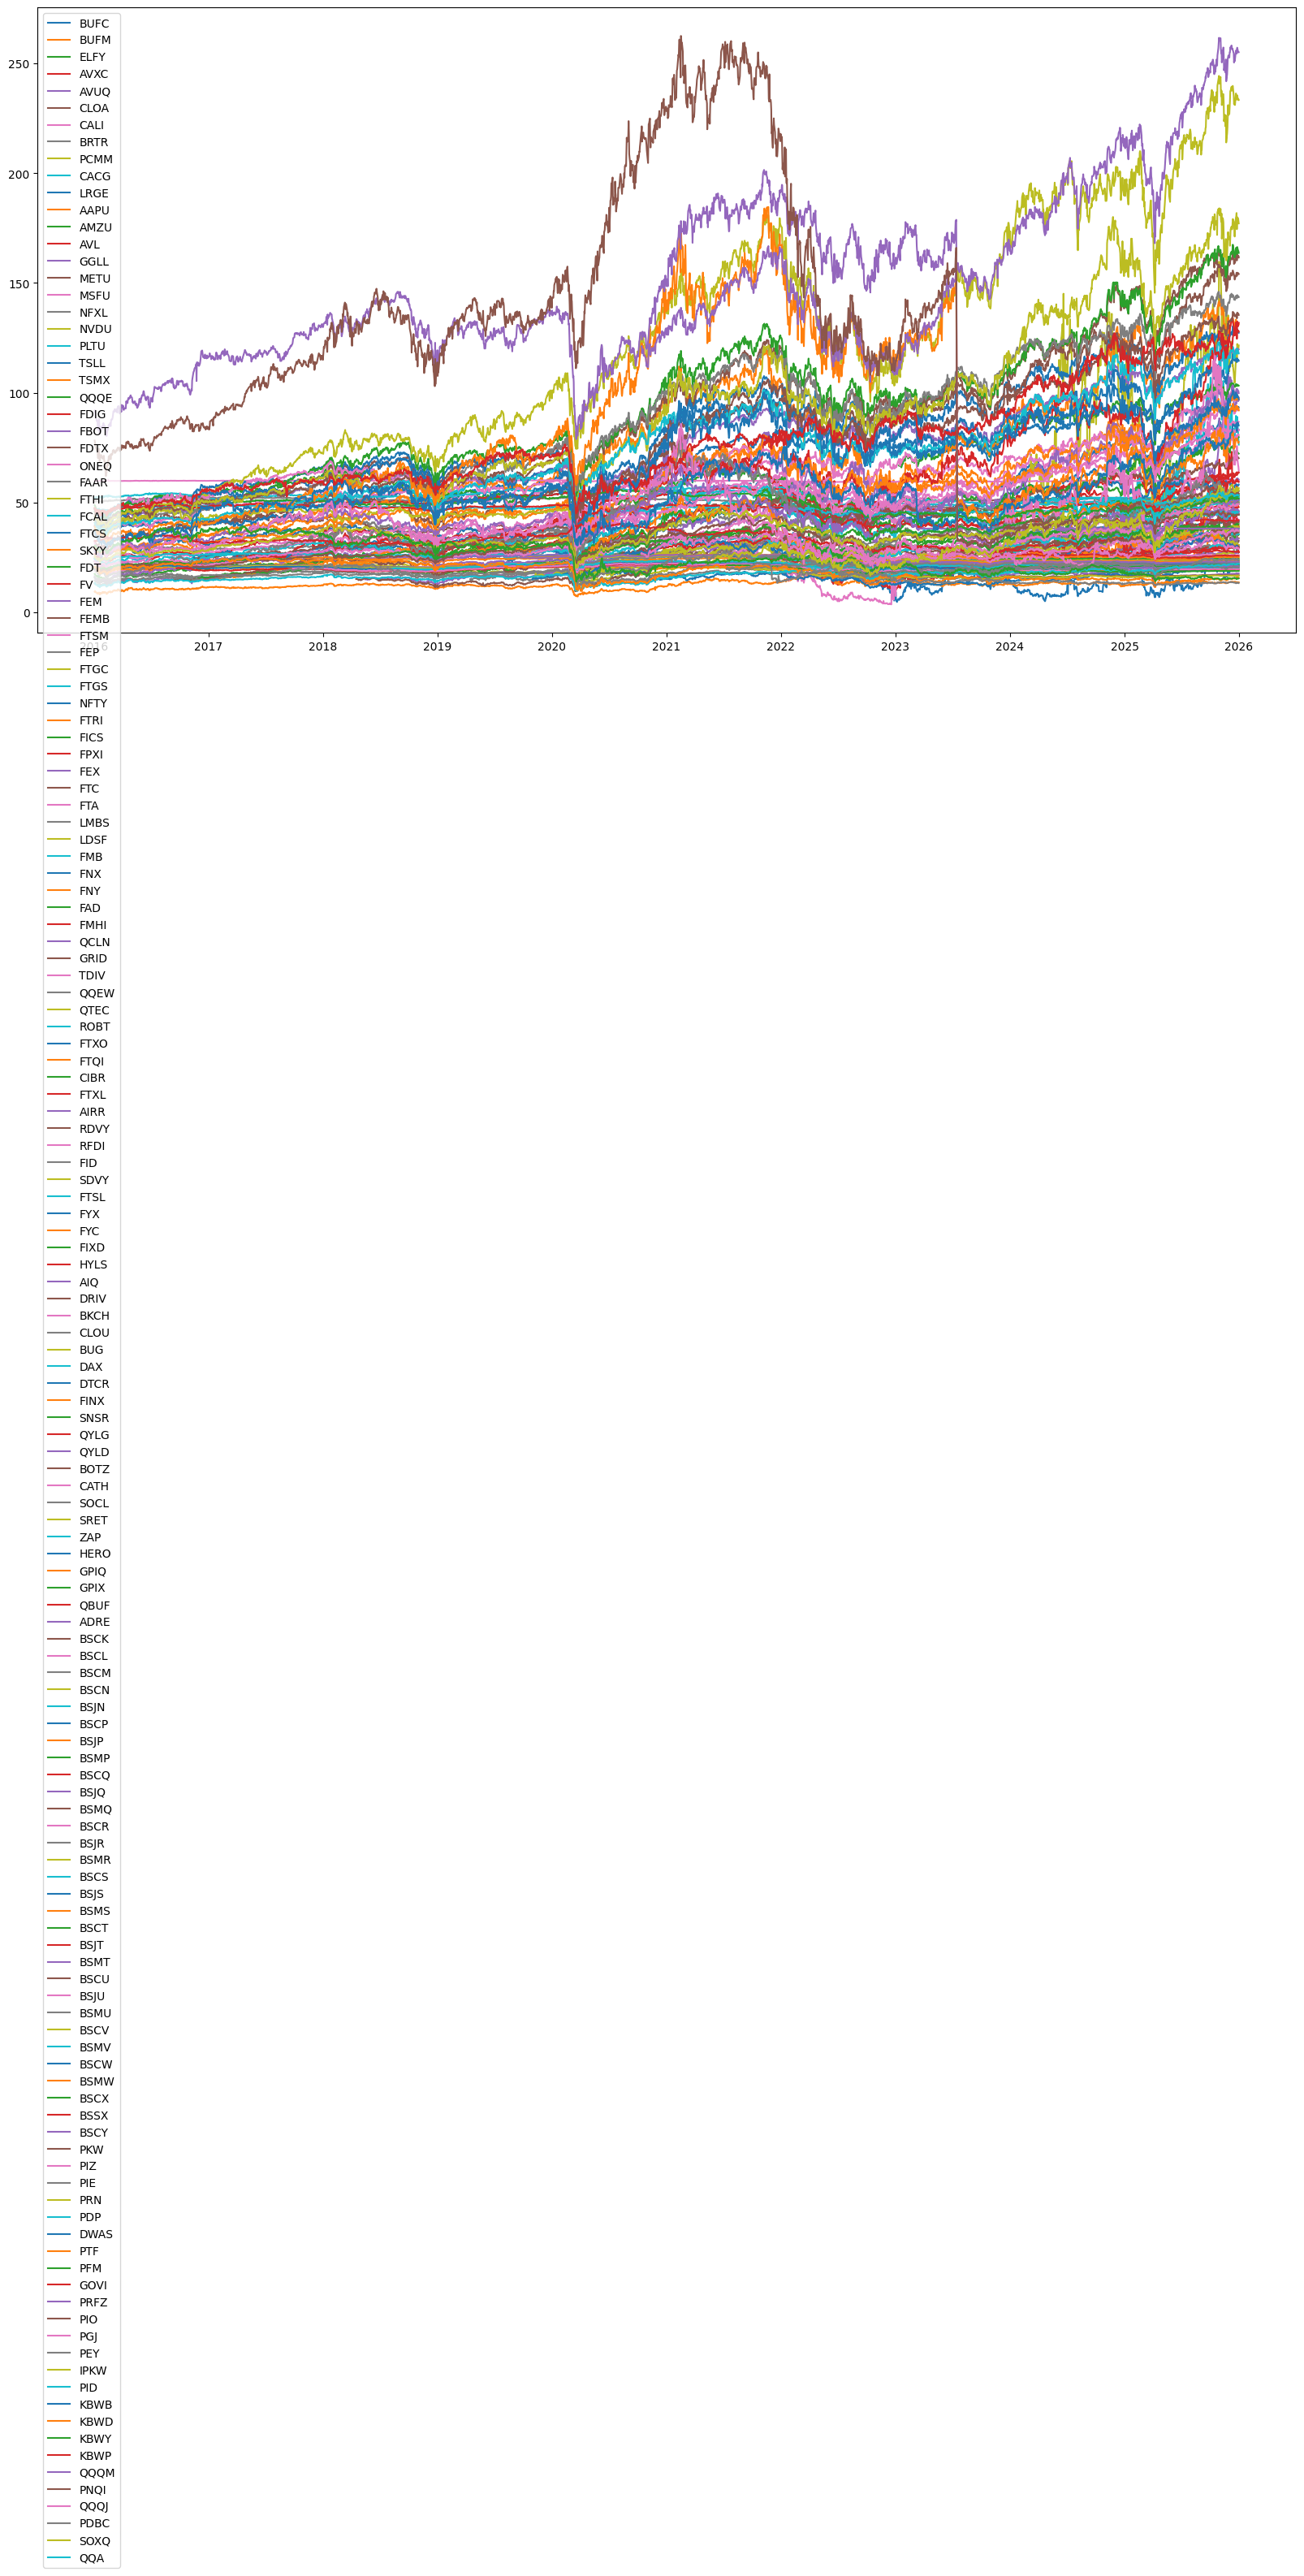

In [32]:
plt.figure(figsize=(20,10))
for code in etf_codes[:150]:
    plt.plot(df_stats[code]['Date'], df_stats[code][df_stats[code].columns[1]], label=tickers[etf_codes.index(code)])

plt.legend()


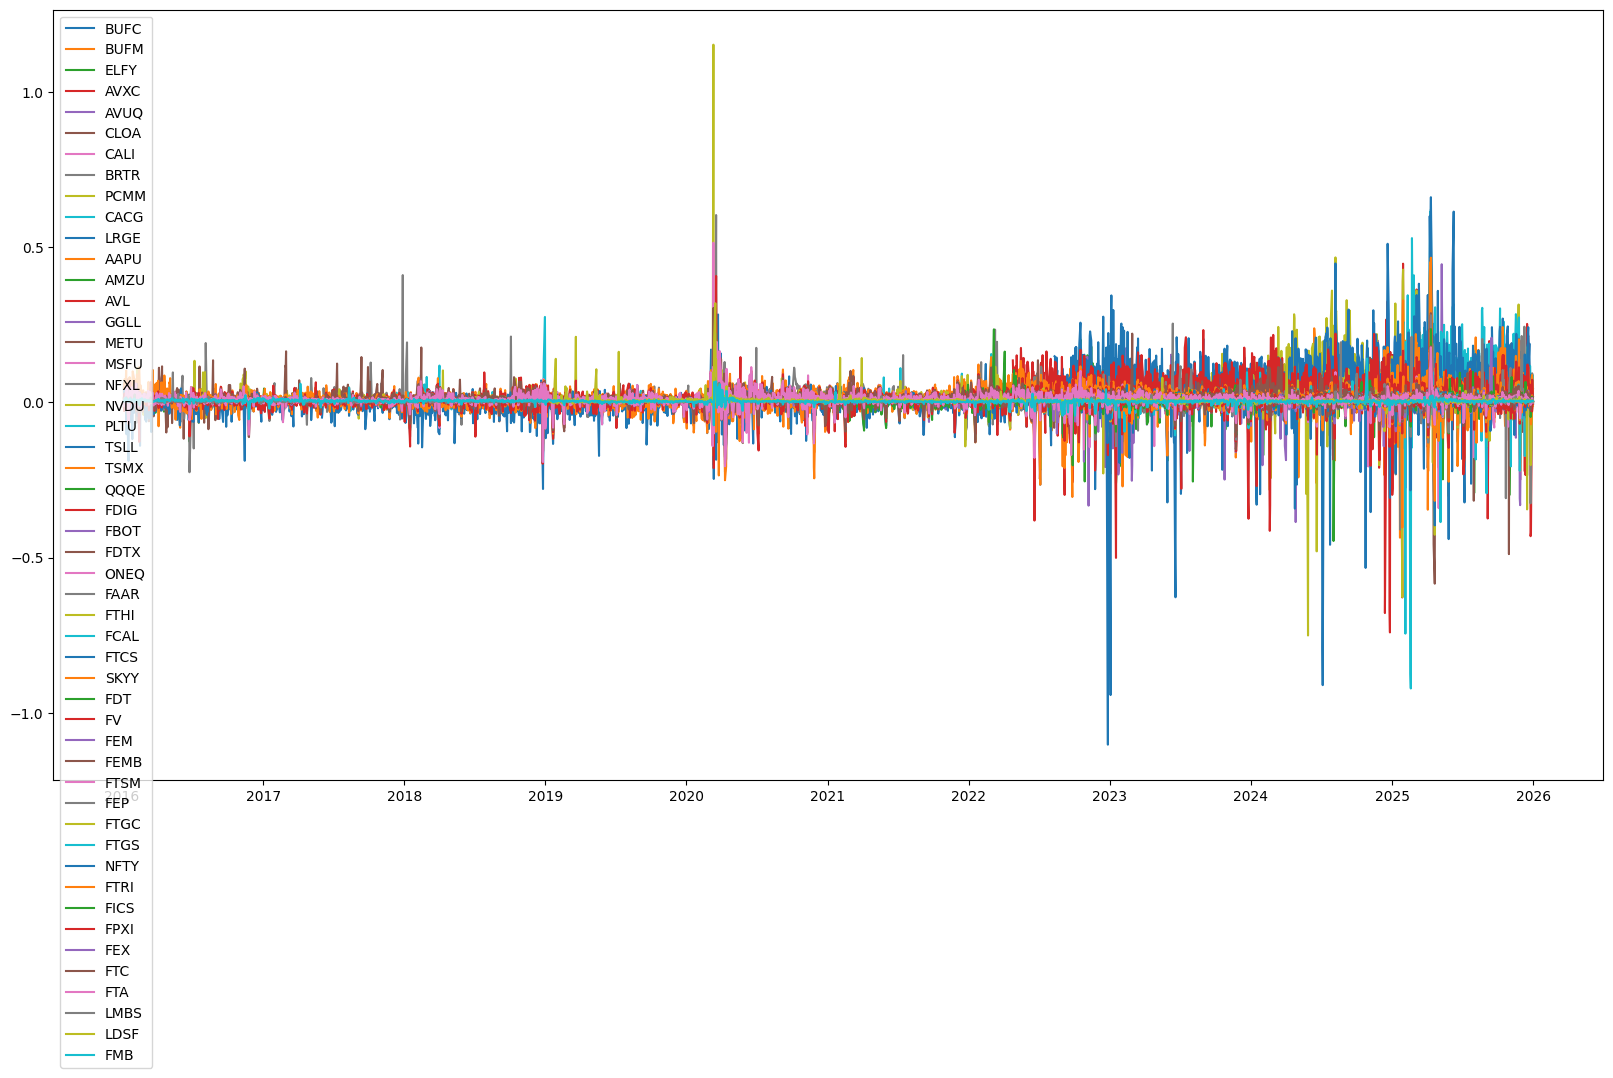

In [79]:
plt.figure(figsize=(20,10))
for code in etf_codes[:50]:
    plt.plot(df_stats[code]['Date'], df_stats[code][df_stats[code].columns[-1]], label=tickers[etf_codes.index(code)])

plt.legend()


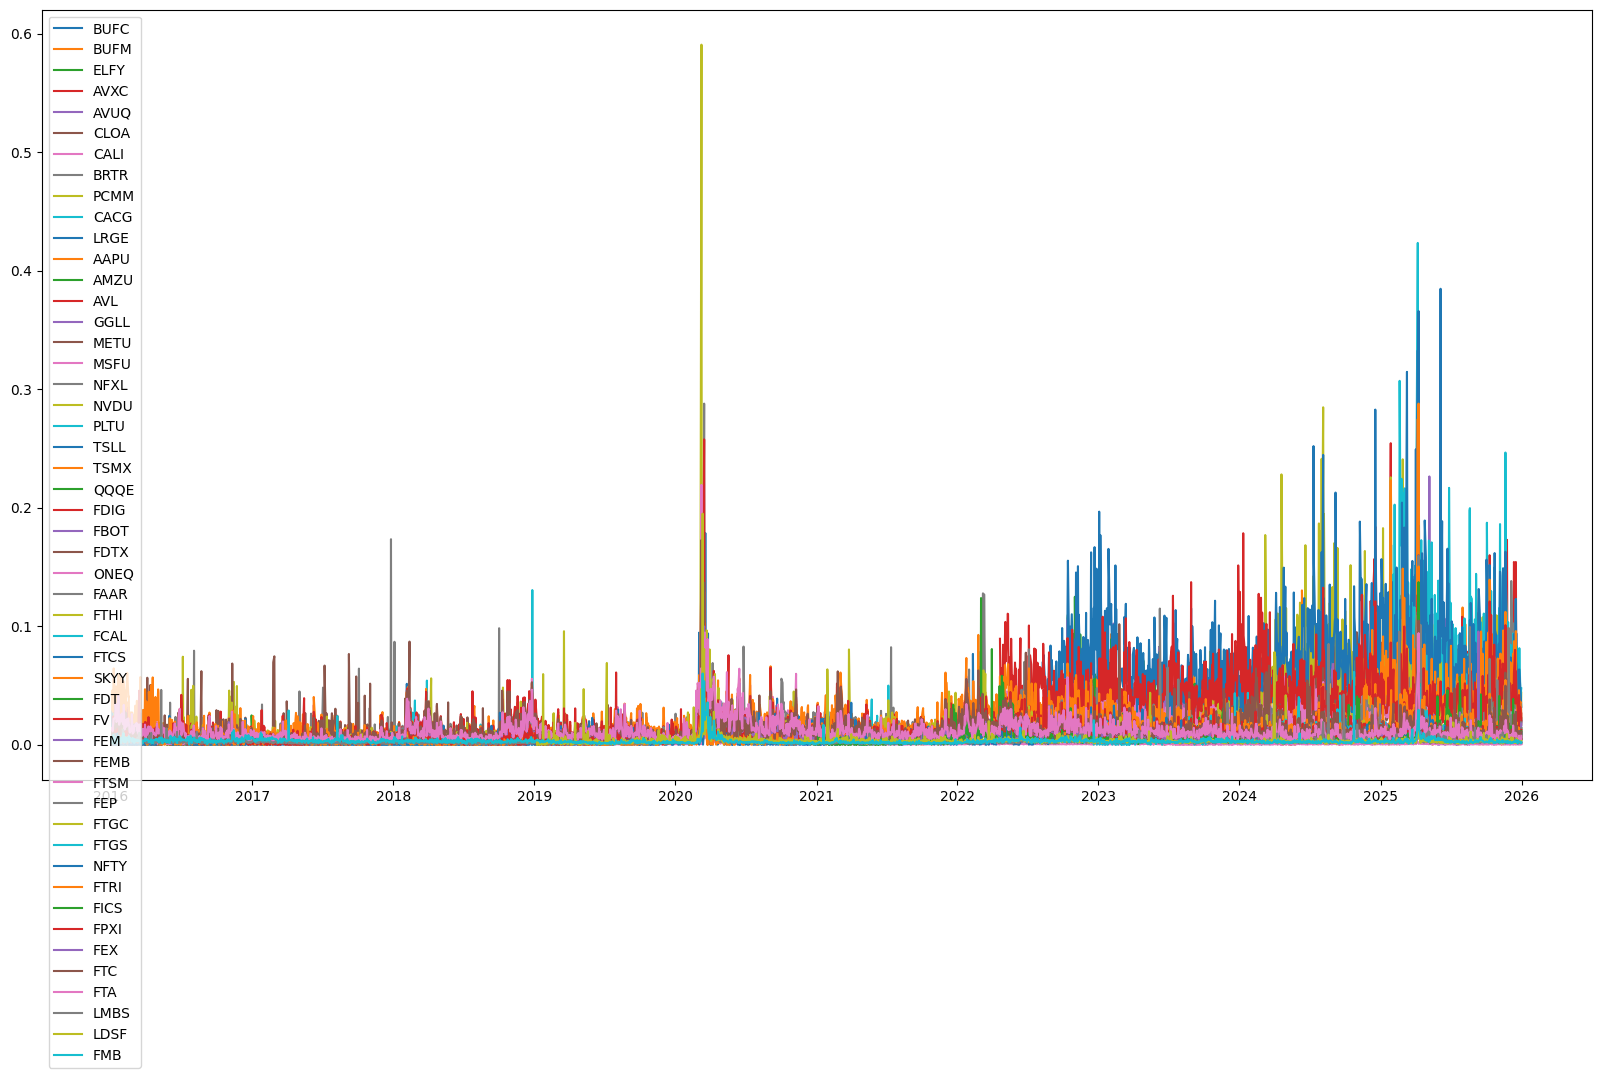

In [64]:
plt.figure(figsize=(20,10))
for code in etf_codes[:50]:
    plt.plot(df_stats[code]['Date'], df_stats[code][df_stats[code].columns[-1]], label=tickers[etf_codes.index(code)])

plt.legend()


In [ ]:
type(df_dict) == dict[str, pd.DataFrame], type(df_dict[NAMES[0]]['ISIN']) == pd.Series, type(df_dict[NAMES[0]]['ISIN'].tolist()), set(etf_codes) <= set(df_dict[NAMES[-2]].columns), 


(False, True, list, True)

In [29]:
['MaxPrice VTWG', 'MinPrice VTWG'] in df1.columns.tolist()


False

In [26]:
set(['MaxPrice VTWG', 'MinPrice VTWG']) <= set(df1.columns)


True

In [ ]:
max(np.nan, np.nan), max(np.nan, 1), 1/np.nan


(nan, nan, nan)

In [ ]:
a = pd.Series([1, 2, np.nan, 3, 4, np.nan]).rolling(window=2, min_periods=1)
a


Rolling [window=2,min_periods=1,center=False,axis=0,method=single]

In [ ]:
pd.Series([1, 2, np.nan, 3, 4, np.nan]).shift(1)


0    NaN
1    1.0
2    2.0
3    NaN
4    3.0
5    4.0
dtype: float64